<a href="https://colab.research.google.com/github/Koushiki-git/Academic_Record_Keeper/blob/main/Copy_of_SER_Enhanced_Notebook_New_BKynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition (SER)
**Project Mentor: Phyo Thet Yee**

| Task | Description | Marks |
|---|---|---|
| Task 1 | Emotion Classification Pipeline (MFCC + SSL, 4 pooling, SVM + LR) | 25 |
| Task 2 | Cross-Dataset Generalization (RAVDESS ↔ CREMA-D) | 15 |
| Task 3 | Pooling Strategy Comparison | 10 |

**Datasets:** RAVDESS, CREMA-D  
**Best result:** HuBERT + Mean Pooling → 67.45% Macro-F1 (CREMA-D in-domain)

> ⚠️ Make sure **Runtime → Change runtime type → T4 GPU** is selected before running.

---
## Section 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q librosa soundfile tqdm transformers

Mounted at /content/drive


In [ ]:
import os
BASE_DIR = "/content/drive/MyDrive/ser_project"
for d in ["data/raw/crema_d", "data/raw/ravdess", "data/processed",
           "features", "models", "results"]:
    os.makedirs(f"{BASE_DIR}/{d}", exist_ok=True)
    print(f"Created: {BASE_DIR}/{d}")

Created: /content/drive/MyDrive/ser_project/data/raw/crema_d
Created: /content/drive/MyDrive/ser_project/data/raw/ravdess
Created: /content/drive/MyDrive/ser_project/data/processed
Created: /content/drive/MyDrive/ser_project/features
Created: /content/drive/MyDrive/ser_project/models
Created: /content/drive/MyDrive/ser_project/results


---
## Section 2 — CREMA-D Dataset

In [ ]:
from glob import glob
from collections import Counter
import os

CREMAD_LABEL_MAP = {
    "ANG": "anger", "HAP": "happy", "SAD": "sad",
    "NEU": "neutral", "FEA": "fear", "DIS": None,
}

files = glob("/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/*.wav")
print(f"Total files found: {len(files)}")

records = []
for path in files:
    fname        = os.path.basename(path)
    parts        = fname.replace(".wav", "").split("_")
    if len(parts) < 3: continue
    label = CREMAD_LABEL_MAP.get(parts[2].upper(), None)
    if label is None: continue
    records.append({"path": path, "speaker_id": f"cremad_{parts[0]}", "label": label})

print(f"Total records: {len(records)}")
for label, count in sorted(Counter(r['label'] for r in records).items()):
    print(f"  {label:<10} {count}")

Total files found: 1000
Total records: 829
  anger      172
  fear       171
  happy      171
  neutral    144
  sad        171


In [ ]:
import requests

url = "https://api.github.com/repos/CheyneyComputerScience/CREMA-D/contents/AudioWAV"
response = requests.get(url)
files = response.json()

records = []

for f in files:
    fname = f["name"]

    # Extract emotion from filename
    parts = fname.split("_")
    emotion_code = parts[2]

    emotion_map = {
        "ANG": "angry",
        "DIS": "disgust",
        "FEA": "fear",
        "HAP": "happy",
        "NEU": "neutral",
        "SAD": "sad"
    }

    if emotion_code in emotion_map:
        records.append({
            "file_name": fname,
            "emotion": emotion_map[emotion_code]
        })

print("Total records:", len(records))

Total records: 1000


In [ ]:
import pandas as pd
print(type(records))
print(len(records))
print(records[:3])   # first few entries

df = pd.DataFrame(records)
print(df.columns)
print(df.head())

<class 'list'>
1000
[{'file_name': '1001_DFA_ANG_XX.wav', 'emotion': 'angry'}, {'file_name': '1001_DFA_DIS_XX.wav', 'emotion': 'disgust'}, {'file_name': '1001_DFA_FEA_XX.wav', 'emotion': 'fear'}]
Index(['file_name', 'emotion'], dtype='object')
             file_name  emotion
0  1001_DFA_ANG_XX.wav    angry
1  1001_DFA_DIS_XX.wav  disgust
2  1001_DFA_FEA_XX.wav     fear
3  1001_DFA_HAP_XX.wav    happy
4  1001_DFA_NEU_XX.wav  neutral


In [ ]:
# Download real CREMA-D audio — skip if already downloaded
import requests
from tqdm import tqdm
import pandas as pd

save_dir = "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV"
os.makedirs(save_dir, exist_ok=True)
df = pd.DataFrame(records)
base_url = "https://media.githubusercontent.com/media/CheyneyComputerScience/CREMA-D/master/AudioWAV"
skipped, failed = 0, []
for fname in tqdm(df["file_name"], desc="Downloading CREMA-D"):
    out_path = os.path.join(save_dir, fname)
    if os.path.exists(out_path) and os.path.getsize(out_path) > 1000:
        skipped += 1; continue
    try:
        r = requests.get(f"{base_url}/{fname}", timeout=30)
        if r.status_code == 200:
            with open(out_path, "wb") as f: f.write(r.content)
        else: failed.append(fname)
    except: failed.append(fname)

print(f"Done! Skipped: {skipped} | Failed: {len(failed)}")
real = [f for f in os.listdir(save_dir) if os.path.getsize(os.path.join(save_dir, f)) > 1000]
print(f"Real audio files: {len(real)}")

Done! Skipped: 1000 | Failed: 0
Real audio files: 1000


---
## Section 3 — Audio Preprocessing
Pipeline: **Load → Mono → Resample 16kHz → Trim silence → Peak normalize**

In [ ]:
import librosa
import numpy as np
import soundfile as sf

def preprocess_clip(path):
    """Full preprocessing pipeline: mono → 16kHz → trim → normalize."""
    audio, sr = librosa.load(path, sr=None, mono=False)
    if audio.ndim > 1: audio = audio.mean(axis=0)
    if sr != 16000: audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    audio, _ = librosa.effects.trim(audio, top_db=20)
    audio = audio / (np.max(np.abs(audio)) + 1e-9)
    return audio.astype(np.float32)

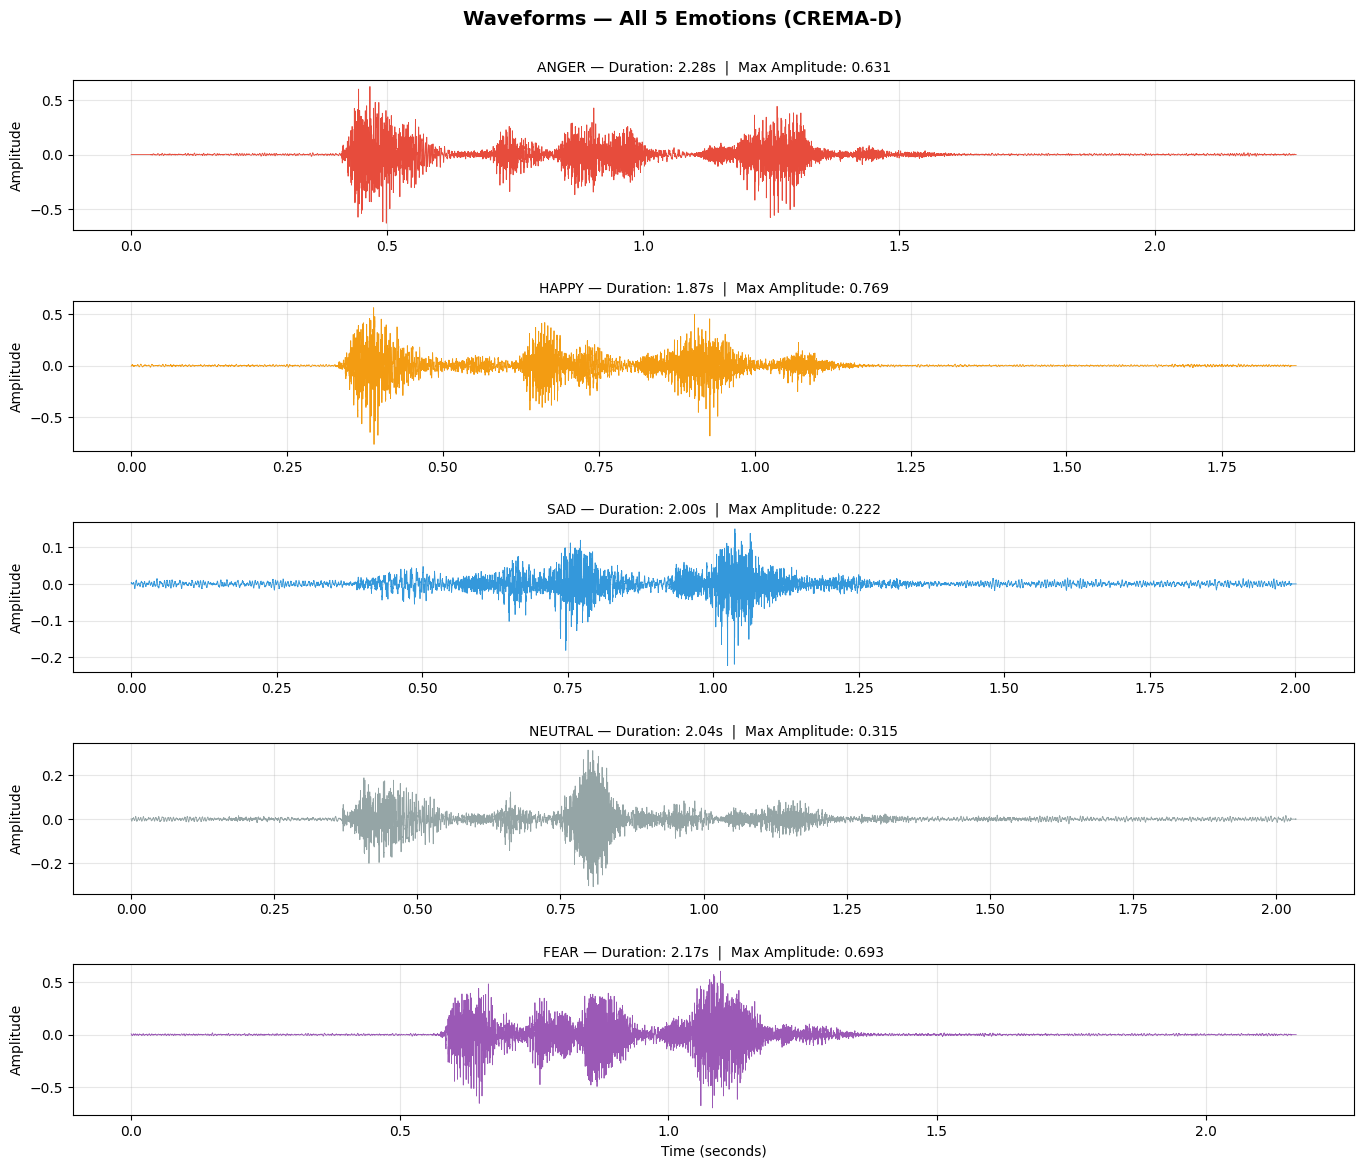

Saved!


In [ ]:
# ── Visualization 1: Waveforms for all 5 emotions ──────────────────────────
import matplotlib.pyplot as plt

emotion_files = {
    "anger"  : "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/1001_DFA_ANG_XX.wav",
    "happy"  : "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/1001_DFA_HAP_XX.wav",
    "sad"    : "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/1001_DFA_SAD_XX.wav",
    "neutral": "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/1001_DFA_NEU_XX.wav",
    "fear"   : "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/1001_DFA_FEA_XX.wav",
}

colors = {"anger": "#e74c3c", "happy": "#f39c12", "sad": "#3498db",
          "neutral": "#95a5a6", "fear": "#9b59b6"}

fig, axes = plt.subplots(5, 1, figsize=(14, 12))
fig.suptitle("Waveforms — All 5 Emotions (CREMA-D)", fontsize=14, fontweight='bold')

for i, (emotion, path) in enumerate(emotion_files.items()):
    audio, sr = librosa.load(path, sr=16000)
    t = np.linspace(0, len(audio)/sr, len(audio))
    axes[i].plot(t, audio, color=colors[emotion], linewidth=0.6)
    axes[i].set_title(f"{emotion.upper()} — Duration: {len(audio)/sr:.2f}s  |  Max Amplitude: {np.max(np.abs(audio)):.3f}",
                      fontsize=10)
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout(pad=2.0)
plt.savefig("/content/drive/MyDrive/ser_project/results/waveforms_5_emotions.png", dpi=150)
plt.show()
print("Saved!")

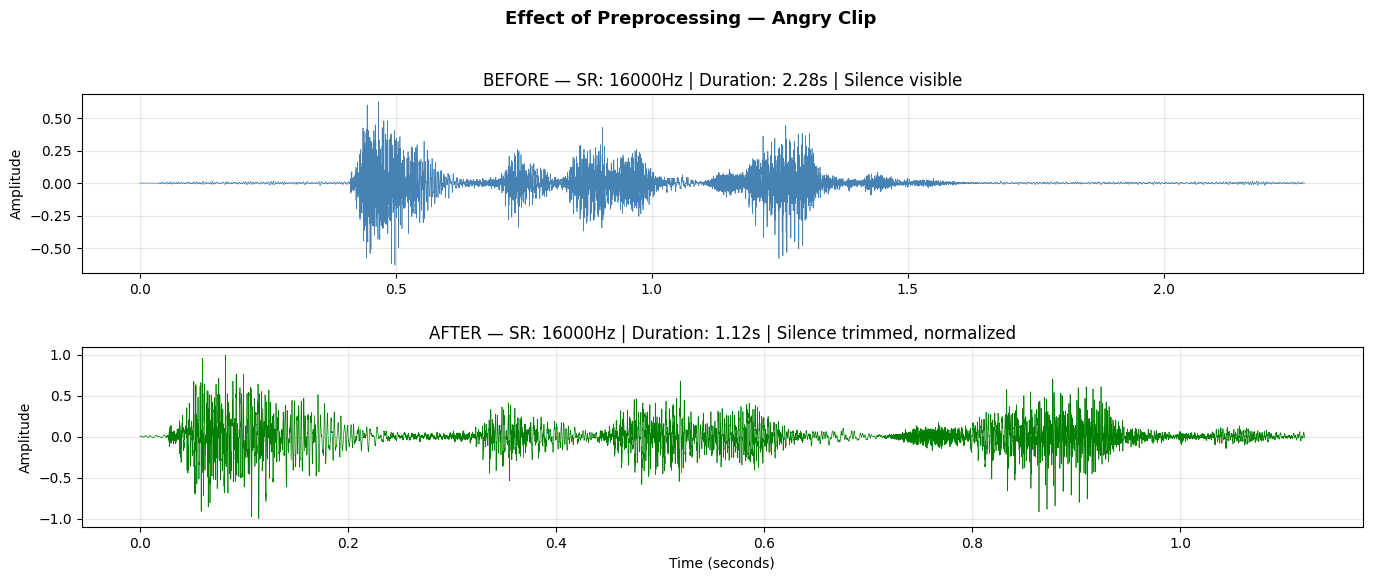

In [ ]:
# ── Visualization 2: Before vs After Preprocessing ─────────────────────────
sample_path = "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/1001_DFA_ANG_XX.wav"

audio_raw, sr_raw = librosa.load(sample_path, sr=None)
audio_clean       = preprocess_clip(sample_path)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle("Effect of Preprocessing — Angry Clip", fontsize=13, fontweight='bold')

t1 = np.linspace(0, len(audio_raw)/sr_raw, len(audio_raw))
axes[0].plot(t1, audio_raw, color='steelblue', linewidth=0.5)
axes[0].set_title(f"BEFORE — SR: {sr_raw}Hz | Duration: {len(audio_raw)/sr_raw:.2f}s | Silence visible")
axes[0].set_ylabel("Amplitude"); axes[0].grid(True, alpha=0.3)

t2 = np.linspace(0, len(audio_clean)/16000, len(audio_clean))
axes[1].plot(t2, audio_clean, color='green', linewidth=0.5)
axes[1].set_title(f"AFTER — SR: 16000Hz | Duration: {len(audio_clean)/16000:.2f}s | Silence trimmed, normalized")
axes[1].set_ylabel("Amplitude"); axes[1].set_xlabel("Time (seconds)"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(pad=2.0)
plt.savefig("/content/drive/MyDrive/ser_project/results/preprocessing_comparison.png", dpi=150)
plt.show()

In [ ]:
import os
import pandas as pd

audio_dir = "/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV"

files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

emotion_map = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}

records = []

for fname in files:
    parts = fname.split("_")
    emotion_code = parts[2]

    records.append({
        "file_name": fname,
        "path": os.path.join(audio_dir, fname),   # ✅ critical
        "emotion": emotion_map.get(emotion_code, "unknown")
    })

df = pd.DataFrame(records)

In [ ]:
print(df.columns)
print(df.head())

assert "path" in df.columns
assert os.path.exists(df["path"].iloc[0])

Index(['file_name', 'path', 'emotion'], dtype='object')
             file_name                                               path  \
0  1001_DFA_ANG_XX.wav  /content/drive/MyDrive/ser_project/data/raw/cr...   
1  1001_DFA_DIS_XX.wav  /content/drive/MyDrive/ser_project/data/raw/cr...   
2  1001_DFA_FEA_XX.wav  /content/drive/MyDrive/ser_project/data/raw/cr...   
3  1001_DFA_HAP_XX.wav  /content/drive/MyDrive/ser_project/data/raw/cr...   
4  1001_DFA_NEU_XX.wav  /content/drive/MyDrive/ser_project/data/raw/cr...   

   emotion  
0    angry  
1  disgust  
2     fear  
3    happy  
4  neutral  


In [ ]:
import soundfile as sf
from tqdm import tqdm

save_proc_dir = "/content/drive/MyDrive/ser_project/data/processed/crema_d"
os.makedirs(save_proc_dir, exist_ok=True)

skipped, failed = 0, []

for rec in tqdm(df.to_dict(orient="records"), total=len(df), desc="Preprocessing CREMA-D"):
    in_path = rec["path"]
    out_path = os.path.join(save_proc_dir, os.path.basename(in_path))

    if os.path.exists(out_path):
        skipped += 1
        continue

    try:
        audio = preprocess_clip(in_path)
        sf.write(out_path, audio, 16000, subtype="PCM_16")
    except Exception:
        failed.append(in_path)

print(f"Done! Skipped: {skipped} | Failed: {len(failed)}")

Preprocessing CREMA-D: 100%|██████████| 1000/1000 [00:03<00:00, 314.72it/s]

Done! Skipped: 1000 | Failed: 0


In [ ]:
# Preprocess all CREMA-D clips
import pandas as pd
from tqdm import tqdm

df = pd.DataFrame(records)
save_proc_dir = "/content/drive/MyDrive/ser_project/data/processed/crema_d"
os.makedirs(save_proc_dir, exist_ok=True)
skipped, failed = 0, []

for rec in tqdm(df.itertuples(index=False), total=len(df), desc="Preprocessing CREMA-D"):
    out_path = os.path.join(save_proc_dir, os.path.basename(rec.path))

    if os.path.exists(out_path):
        skipped += 1
        continue

    try:
        audio = preprocess_clip(rec.path)

        if audio is None or len(audio) == 0:
            failed.append(rec.path)
            continue

        sf.write(out_path, audio, 16000, subtype="PCM_16")

    except Exception as e:
        failed.append(rec.path)

print(f"Done! Skipped: {skipped} | Failed: {len(failed)}")
df["processed_path"] = df["path"].apply(lambda p: os.path.join(save_proc_dir, os.path.basename(p)))
df.to_csv("/content/drive/MyDrive/ser_project/data/processed/crema_d_manifest.csv", index=False)
print(f"Manifest saved: {len(df)} rows")

Preprocessing CREMA-D: 100%|██████████| 1000/1000 [00:00<00:00, 5204.29it/s]


Done! Skipped: 1000 | Failed: 0
Manifest saved: 1000 rows


---
## Section 4 — RAVDESS Dataset

In [ ]:
# Step 1: Download ZIP only (no unzip)
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p /content

# Step 2: Move ZIP to Drive (very fast, single file)
!cp /content/ravdess-emotional-speech-audio.zip \
    /content/drive/MyDrive/ser_project/data/raw/

# Step 3: Unzip INSIDE Drive (only once)
!unzip -q /content/drive/MyDrive/ser_project/data/raw/ravdess-emotional-speech-audio.zip \
    -d /content/drive/MyDrive/ser_project/data/raw/ravdess

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:07<00:00, 60.6MB/s]

replace /content/drive/MyDrive/ser_project/data/raw/ravdess/Actor_01/03-01-01-01-01-01-01.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
RAVDESS_LABEL_MAP = {
    "01": "neutral", "02": None, "03": "happy", "04": "sad",
    "05": "anger",   "06": "fear", "07": None,  "08": None,
}

files_rav = glob("/content/drive/MyDrive/ser_project/data/raw/ravdess/**/*.wav", recursive=True)
print(f"Total files: {len(files_rav)}")

records_ravdess = []
for path in files_rav:
    parts = os.path.basename(path).replace(".wav", "").split("-")
    if len(parts) != 7: continue
    label = RAVDESS_LABEL_MAP.get(parts[2], None)
    if label is None: continue
    records_ravdess.append({"path": path, "speaker_id": f"ravdess_{parts[6]}", "label": label})

print(f"Total records: {len(records_ravdess)}")
for label, count in sorted(Counter(r['label'] for r in records_ravdess).items()):
    print(f"  {label:<10} {count}")

Total files: 2880
Total records: 1728
  anger      384
  fear       384
  happy      384
  neutral    192
  sad        384


In [ ]:
df_ravdess = pd.DataFrame(records_ravdess)
save_proc_dir_rav = "/content/drive/MyDrive/ser_project/data/processed/ravdess"
os.makedirs(save_proc_dir_rav, exist_ok=True)
skipped, failed = 0, []

for rec in tqdm(df_ravdess.itertuples(), total=len(df_ravdess), desc="Preprocessing RAVDESS"):
    out_path = os.path.join(save_proc_dir_rav, os.path.basename(rec.path))
    if os.path.exists(out_path): skipped += 1; continue
    try:
        sf.write(out_path, preprocess_clip(rec.path), 16000, subtype="PCM_16")
    except: failed.append(rec.path)

print(f"Done! Skipped: {skipped} | Failed: {len(failed)}")
df_ravdess["processed_path"] = df_ravdess["path"].apply(
    lambda p: os.path.join(save_proc_dir_rav, os.path.basename(p)))
df_ravdess.to_csv("/content/drive/MyDrive/ser_project/data/processed/ravdess_manifest.csv", index=False)
print(f"Manifest saved: {len(df_ravdess)} rows")

Preprocessing RAVDESS: 100%|██████████| 1728/1728 [00:02<00:00, 585.70it/s] 


Done! Skipped: 1728 | Failed: 0
Manifest saved: 1728 rows


---
## Section 5 — Dataset Statistics & Visualizations

In [ ]:
print("CREMA-D sample:", records[0] if len(records) else "EMPTY")
print("RAVDESS sample:", records_ravdess[0] if len(records_ravdess) else "EMPTY")

CREMA-D sample: {'file_name': '1001_DFA_ANG_XX.wav', 'path': '/content/drive/MyDrive/ser_project/data/raw/crema_d/AudioWAV/1001_DFA_ANG_XX.wav', 'emotion': 'angry'}
RAVDESS sample: {'path': '/content/drive/MyDrive/ser_project/data/raw/ravdess/Actor_01/03-01-01-01-01-01-01.wav', 'speaker_id': 'ravdess_01', 'label': 'neutral'}


In [ ]:
from collections import Counter

# Define colors
palette = [
    "#e74c3c", "#3498db", "#2ecc71", "#f1c40f",
    "#9b59b6", "#1abc9c", "#e67e22", "#95a5a6"
]

def get_label(r):
    if "label" in r:
        return r["label"]
    elif "emotion" in r:
        return r["emotion"]
    else:
        raise KeyError(f"No label/emotion key in record: {r}")

for ax, (name, recs) in zip(axes, [("CREMA-D", records), ("RAVDESS", records_ravdess)]):

    counts = Counter(get_label(r) for r in recs)

    labels_list = sorted(counts.keys())
    values = [counts[l] for l in labels_list]

    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels_list,
        autopct='%1.1f%%',
        colors=palette,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    for at in autotexts:
        at.set_fontsize(9)

    ax.set_title(f"{name} ({sum(values)} clips)", fontsize=12, fontweight='bold')

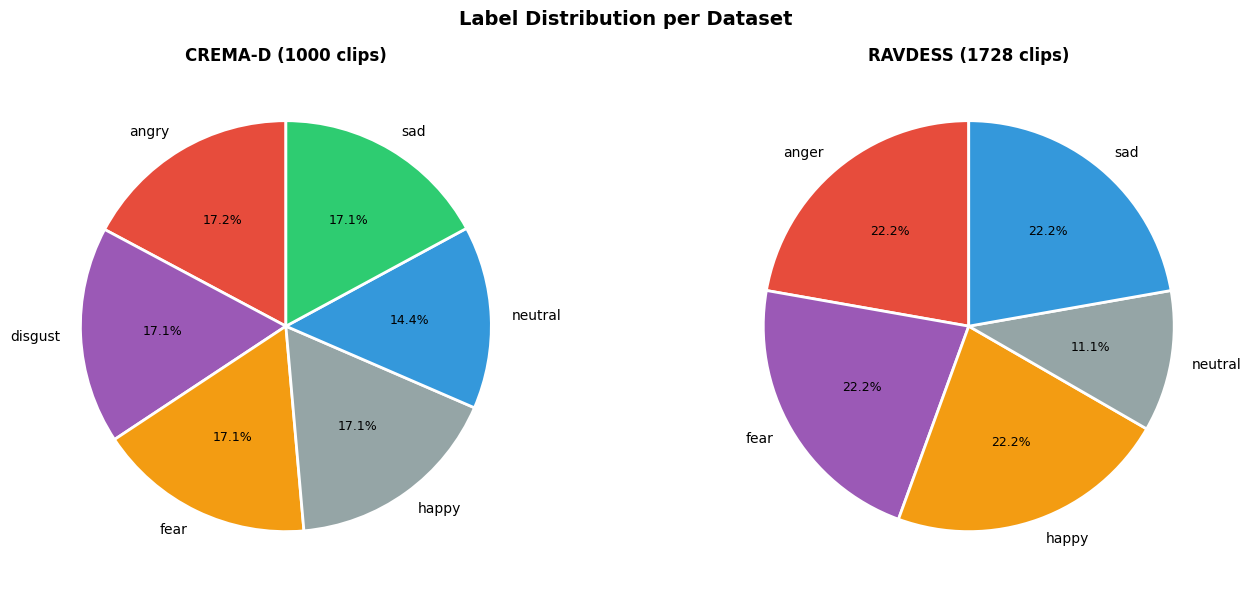

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# --- Safe label extractor ---
def get_label(r):
    if "label" in r:
        return r["label"]
    elif "emotion" in r:
        return r["emotion"]
    else:
        return "unknown"   # fallback (prevents crash)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Label Distribution per Dataset", fontsize=14, fontweight='bold')

palette = ["#e74c3c", "#9b59b6", "#f39c12", "#95a5a6", "#3498db", "#2ecc71", "#1abc9c"]

for ax, (name, recs) in zip(axes, [("CREMA-D", records), ("RAVDESS", records_ravdess)]):

    # Extract labels safely
    labels = [get_label(r) for r in recs if r is not None]

    # Count
    counts = Counter(labels)

    labels_list = sorted(counts.keys())
    values = [counts[l] for l in labels_list]

    # Plot pie
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels_list,
        autopct='%1.1f%%',
        colors=palette[:len(labels_list)],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    for at in autotexts:
        at.set_fontsize(9)

    ax.set_title(f"{name} ({sum(values)} clips)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/label_distribution.png", dpi=150)
plt.show()

Computing durations...


RAVDESS durations: 100%|██████████| 1728/1728 [04:01<00:00,  7.15it/s] 


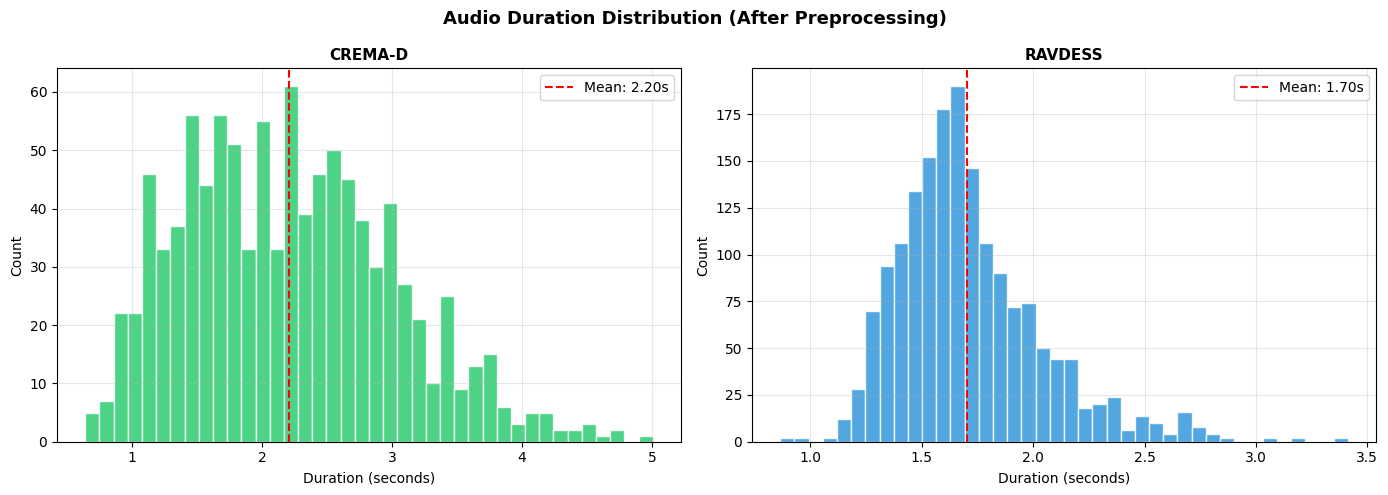

In [ ]:
# ── Visualization 4: Audio Duration Distribution ───────────────────────────
print("Computing durations...")

durations_crem, durations_rav = [], []

for rec in tqdm(df.itertuples(), total=len(df), desc="CREMA-D durations"):
    try:
        info = sf.info(rec.processed_path)
        durations_crem.append(info.frames / 16000)
    except: pass

for rec in tqdm(df_ravdess.itertuples(), total=len(df_ravdess), desc="RAVDESS durations"):
    try:
        info = sf.info(rec.processed_path)
        durations_rav.append(info.frames / 16000)
    except: pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Audio Duration Distribution (After Preprocessing)", fontsize=13, fontweight='bold')

for ax, durations, name, color in zip(
    axes,
    [durations_crem, durations_rav],
    ["CREMA-D", "RAVDESS"],
    ["#2ecc71", "#3498db"]
):
    ax.hist(durations, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(durations), color='red', linestyle='--', linewidth=1.5,
               label=f"Mean: {np.mean(durations):.2f}s")
    ax.set_title(f"{name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/duration_distribution.png", dpi=150)
plt.show()

---
## Section 6 — Feature Extraction
### 6A — MFCC Features

In [ ]:
def extract_mfcc(path, n_mfcc=40, n_fft=512, hop_length=160, win_length=400):
    """Extract MFCC + Delta + Delta-Delta. Returns shape [120, T]."""
    audio, sr = librosa.load(path, sr=16000)
    mfcc   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc,
                                   n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.vstack([mfcc, delta, delta2])

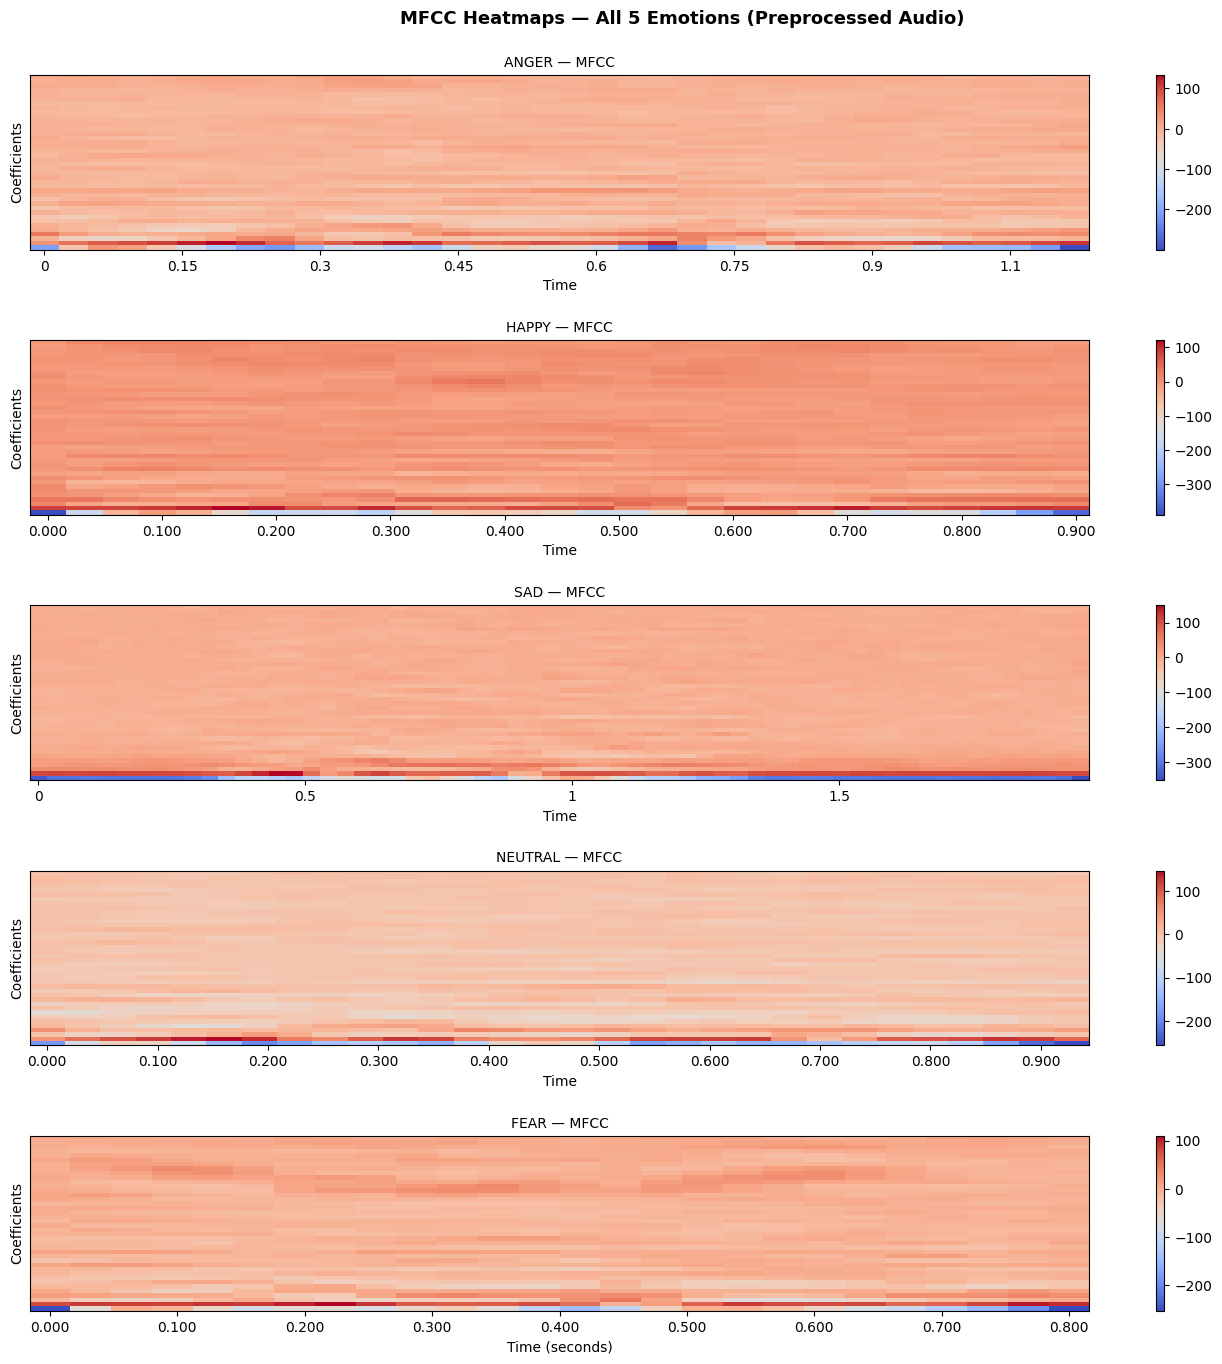

In [ ]:
# ── Visualization 5: MFCC Heatmap — All 5 Emotions ────────────────────────
import librosa.display

fig, axes = plt.subplots(5, 1, figsize=(14, 14))
fig.suptitle("MFCC Heatmaps — All 5 Emotions (Preprocessed Audio)", fontsize=13, fontweight='bold')

for i, (emotion, path) in enumerate(emotion_files.items()):
    audio = preprocess_clip(path)
    mfcc  = librosa.feature.mfcc(y=audio, sr=16000, n_mfcc=40)
    img   = librosa.display.specshow(mfcc, sr=16000, x_axis='time', ax=axes[i])
    axes[i].set_title(f"{emotion.upper()} — MFCC", fontsize=10)
    axes[i].set_ylabel("Coefficients")
    fig.colorbar(img, ax=axes[i])

axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout(pad=2.0)
plt.savefig("/content/drive/MyDrive/ser_project/results/mfcc_heatmaps.png", dpi=150)
plt.show()

### 6B — SSL Features (HuBERT)

In [ ]:
import torch
from transformers import Wav2Vec2FeatureExtractor, HubertModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print("Loading HuBERT...")
hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
hubert_model     = HubertModel.from_pretrained("facebook/hubert-base-ls960").to(device)
hubert_model.eval()
print(f"HuBERT loaded on: {device}")

Device: cuda
Loading HuBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HuBERT loaded on: cuda


In [ ]:
def extract_hubert_features(path):
    """Returns [T, 768]"""

    audio = preprocess_clip(path)   # IMPORTANT FIX

    inputs = hubert_processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = hubert_model(input_values)

    return outputs.last_hidden_state.squeeze(0).cpu().numpy()

In [ ]:
def mean_pooling(f):
    return np.mean(f, axis=0)

def max_pooling(f):
    return np.max(f, axis=0)

def mean_std_pooling(f):
    return np.concatenate([
        np.mean(f, axis=0),
        np.std(f, axis=0)
    ])

def attention_pooling(f):
    e = np.sum(f**2, axis=1)
    e = e - np.max(e)
    w = np.exp(e) / np.sum(np.exp(e))
    return np.sum(f * w[:, None], axis=0)

In [ ]:
def extract_hubert_features(path):
    """Extract HuBERT embeddings. Returns shape [T, 768]."""
    audio, sr    = librosa.load(path, sr=16000)
    inputs       = hubert_processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)
    with torch.no_grad():
        outputs = hubert_model(input_values)
    return outputs.last_hidden_state.squeeze(0).cpu().numpy()

---
## Section 7 — Pooling Methods (Task 3)

In [ ]:
def mean_pooling(f):     return np.mean(f, axis=1)
def max_pooling(f):      return np.max(f, axis=1)
def mean_std_pooling(f): return np.concatenate([np.mean(f, axis=1), np.std(f, axis=1)])
def attention_pooling(f):
    e = np.sum(f**2, axis=0); e = e - np.max(e)
    w = np.exp(e) / np.sum(np.exp(e))
    return np.dot(f, w)

print("Pooling functions defined!")

Pooling functions defined!


---
## Section 8 — Extract & Save All Features

In [ ]:
print(df.columns)

Index(['file_name', 'path', 'emotion', 'processed_path'], dtype='object')


In [ ]:
for rec in tqdm(df.itertuples(), total=len(df), desc="MFCC — CREMA-D"):
    try:
        f = extract_mfcc(rec.processed_path)

        all_mean.append(mean_pooling(f))
        all_max.append(max_pooling(f))
        all_meanstd.append(mean_std_pooling(f))
        all_attn.append(attention_pooling(f))

        # ✅ FIXED
        all_labels.append(rec.emotion)

        # ✅ FIXED (speaker extraction)
        speaker = rec.file_name.split("_")[0]
        all_speakers.append(speaker)

    except Exception as e:
        print(f"Failed at {rec.processed_path}: {e}")

MFCC — CREMA-D: 100%|██████████| 1000/1000 [00:18<00:00, 55.02it/s] 


In [ ]:
features_dir = "/content/drive/MyDrive/ser_project/features"
os.makedirs(features_dir, exist_ok=True)

all_mean, all_max, all_meanstd, all_attn = [], [], [], []
all_labels, all_speakers = [], []

for rec in tqdm(df.itertuples(), total=len(df), desc="MFCC — CREMA-D"):
    try:
        f = extract_mfcc(rec.processed_path)

        all_mean.append(mean_pooling(f))
        all_max.append(max_pooling(f))
        all_meanstd.append(mean_std_pooling(f))
        all_attn.append(attention_pooling(f))

        # ✅ correct label
        all_labels.append(rec.emotion)

        # ✅ correct speaker extraction
        speaker = rec.file_name.split("_")[0]
        all_speakers.append(speaker)

    except Exception as e:
        print(f"Failed at {rec.processed_path}: {e}")

# Save
np.save(f"{features_dir}/X_mean.npy",    np.array(all_mean))
np.save(f"{features_dir}/X_max.npy",     np.array(all_max))
np.save(f"{features_dir}/X_meanstd.npy", np.array(all_meanstd))
np.save(f"{features_dir}/X_attn.npy",    np.array(all_attn))
np.save(f"{features_dir}/y.npy",         np.array(all_labels))
np.save(f"{features_dir}/speakers.npy",  np.array(all_speakers))

print(f"MFCC saved! Shape: {np.array(all_mean).shape}")

MFCC — CREMA-D: 100%|██████████| 1000/1000 [00:20<00:00, 47.94it/s]


MFCC saved! Shape: (1000, 120)


In [ ]:
# ── Extract MFCC Features for CREMA-D (Final Clean Version) ───────────────

import os
import numpy as np
from tqdm import tqdm

features_dir = "/content/drive/MyDrive/ser_project/features"
os.makedirs(features_dir, exist_ok=True)

all_mean, all_max, all_meanstd, all_attn = [], [], [], []
all_labels, all_speakers = [], []

for rec in tqdm(df.itertuples(), total=len(df), desc="MFCC — CREMA-D"):
    try:
        # 1) Extract MFCC
        f = extract_mfcc(rec.processed_path)

        # 2) Pooling
        all_mean.append(mean_pooling(f))
        all_max.append(max_pooling(f))
        all_meanstd.append(mean_std_pooling(f))
        all_attn.append(attention_pooling(f))

        # 3) Label (FIXED)
        all_labels.append(rec.emotion)

        # 4) Speaker (FIXED from filename)
        speaker = rec.file_name.split("_")[0]
        all_speakers.append(speaker)

    except Exception as e:
        print(f"❌ Failed at {rec.processed_path}: {e}")

# Convert to arrays
X_mean    = np.array(all_mean)
X_max     = np.array(all_max)
X_meanstd = np.array(all_meanstd)
X_attn    = np.array(all_attn)
y         = np.array(all_labels)
speakers  = np.array(all_speakers)

# Save
np.save(f"{features_dir}/X_mean.npy",    X_mean)
np.save(f"{features_dir}/X_max.npy",     X_max)
np.save(f"{features_dir}/X_meanstd.npy", X_meanstd)
np.save(f"{features_dir}/X_attn.npy",    X_attn)
np.save(f"{features_dir}/y.npy",         y)
np.save(f"{features_dir}/speakers.npy",  speakers)

# Final check
print("✅ MFCC features saved successfully!")
print("Shape check:")
print("X_mean   :", X_mean.shape)
print("X_max    :", X_max.shape)
print("X_meanstd:", X_meanstd.shape)
print("X_attn   :", X_attn.shape)
print("Labels   :", y.shape)
print("Speakers :", speakers.shape)

MFCC — CREMA-D: 100%|██████████| 1000/1000 [00:23<00:00, 42.17it/s]


✅ MFCC features saved successfully!
Shape check:
X_mean   : (1000, 120)
X_max    : (1000, 120)
X_meanstd: (1000, 240)
X_attn   : (1000, 120)
Labels   : (1000,)
Speakers : (1000,)


In [ ]:
# Extract HuBERT features for CREMA-D
all_hub_mean, all_hub_max, all_hub_meanstd, all_hub_attn = [], [], [], []

for rec in tqdm(df.itertuples(), total=len(df), desc="HuBERT — CREMA-D"):
    try:
        emb_T = extract_hubert_features(rec.processed_path).T
        all_hub_mean.append(mean_pooling(emb_T)); all_hub_max.append(max_pooling(emb_T))
        all_hub_meanstd.append(mean_std_pooling(emb_T)); all_hub_attn.append(attention_pooling(emb_T))
    except Exception as e: print(f"Failed: {e}")

np.save(f"{features_dir}/X_hubert_mean.npy",    np.array(all_hub_mean))
np.save(f"{features_dir}/X_hubert_max.npy",     np.array(all_hub_max))
np.save(f"{features_dir}/X_hubert_meanstd.npy", np.array(all_hub_meanstd))
np.save(f"{features_dir}/X_hubert_attn.npy",    np.array(all_hub_attn))
print(f"HuBERT CREMA-D saved! Shape: {np.array(all_hub_mean).shape}")

HuBERT — CREMA-D: 100%|██████████| 1000/1000 [00:28<00:00, 34.78it/s]


HuBERT CREMA-D saved! Shape: (1000, 768)


In [ ]:
# Extract HuBERT features for RAVDESS
all_rav_mean, all_rav_max, all_rav_meanstd, all_rav_attn = [], [], [], []
all_rav_labels, all_rav_speakers = [], []

for rec in tqdm(df_ravdess.itertuples(), total=len(df_ravdess), desc="HuBERT — RAVDESS"):
    try:
        emb_T = extract_hubert_features(rec.processed_path).T
        all_rav_mean.append(mean_pooling(emb_T)); all_rav_max.append(max_pooling(emb_T))
        all_rav_meanstd.append(mean_std_pooling(emb_T)); all_rav_attn.append(attention_pooling(emb_T))
        all_rav_labels.append(rec.label); all_rav_speakers.append(rec.speaker_id)
    except Exception as e: print(f"Failed: {e}")

np.save(f"{features_dir}/X_rav_mean.npy",    np.array(all_rav_mean))
np.save(f"{features_dir}/X_rav_max.npy",     np.array(all_rav_max))
np.save(f"{features_dir}/X_rav_meanstd.npy", np.array(all_rav_meanstd))
np.save(f"{features_dir}/X_rav_attn.npy",    np.array(all_rav_attn))
np.save(f"{features_dir}/y_rav.npy",         np.array(all_rav_labels))
np.save(f"{features_dir}/spk_rav.npy",       np.array(all_rav_speakers))
print(f"HuBERT RAVDESS saved! Shape: {np.array(all_rav_mean).shape}")

HuBERT — RAVDESS: 100%|██████████| 1728/1728 [00:31<00:00, 54.05it/s]


HuBERT RAVDESS saved! Shape: (1728, 768)


---
## Section 9 — Reload All Features (Run after session reset)

In [ ]:
import os, numpy as np, torch, librosa, pandas as pd
from transformers import Wav2Vec2FeatureExtractor, HubertModel
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

features_dir = "/content/drive/MyDrive/ser_project/features"
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading HuBERT...")
hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
hubert_model     = HubertModel.from_pretrained("facebook/hubert-base-ls960").to(device)
hubert_model.eval()

# Load all features
X_mean        = np.load(f"{features_dir}/X_mean.npy")
X_max         = np.load(f"{features_dir}/X_max.npy")
X_meanstd     = np.load(f"{features_dir}/X_meanstd.npy")
X_attn        = np.load(f"{features_dir}/X_attn.npy")
X_hubert_mean = np.load(f"{features_dir}/X_hubert_mean.npy")
X_hubert_max  = np.load(f"{features_dir}/X_hubert_max.npy")
X_hubert_meanstd = np.load(f"{features_dir}/X_hubert_meanstd.npy")
X_hubert_attn = np.load(f"{features_dir}/X_hubert_attn.npy")
y             = np.load(f"{features_dir}/y.npy")
speakers      = np.load(f"{features_dir}/speakers.npy")
X_rav_mean    = np.load(f"{features_dir}/X_rav_mean.npy")
X_rav_max     = np.load(f"{features_dir}/X_rav_max.npy")
X_rav_meanstd = np.load(f"{features_dir}/X_rav_meanstd.npy")
X_rav_attn    = np.load(f"{features_dir}/X_rav_attn.npy")
y_rav         = np.load(f"{features_dir}/y_rav.npy")
spk_rav       = np.load(f"{features_dir}/spk_rav.npy")

# Speaker-independent split for CREMA-D
np.random.seed(42)
uniq = np.unique(speakers); np.random.shuffle(uniq)
split      = int(len(uniq) * 0.8)
train_mask = np.isin(speakers, uniq[:split])
test_mask  = np.isin(speakers, uniq[split:])
y_train, y_test = y[train_mask], y[test_mask]

# Speaker-independent split for RAVDESS
np.random.seed(42)
uniq_r = np.unique(spk_rav); np.random.shuffle(uniq_r)
split_r      = int(len(uniq_r) * 0.8)
train_mask_r = np.isin(spk_rav, uniq_r[:split_r])
test_mask_r  = np.isin(spk_rav, uniq_r[split_r:])

print(f"HuBERT on: {device}")
print(f"CREMA-D  — Train: {train_mask.sum()} | Test: {test_mask.sum()}")
print(f"RAVDESS  — Train: {train_mask_r.sum()} | Test: {test_mask_r.sum()}")
print("All variables restored!")

Loading HuBERT...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT on: cuda
CREMA-D  — Train: 754 | Test: 246
RAVDESS  — Train: 1368 | Test: 360
All variables restored!


---
## Section 10 — Classifier Training & Evaluation (Tasks 1 & 3)

In [ ]:
# Helper: train SVM and return predictions + per-class report
def train_svm(X, name, mask_tr=None, mask_te=None, y_tr=None, y_te=None):
    mask_tr = mask_tr if mask_tr is not None else train_mask
    mask_te = mask_te if mask_te is not None else test_mask
    y_tr    = y_tr    if y_tr    is not None else y_train
    y_te    = y_te    if y_te    is not None else y_test
    scaler  = StandardScaler().fit(X[mask_tr])
    clf     = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
    clf.fit(scaler.transform(X[mask_tr]), y_tr)
    y_pred   = clf.predict(scaler.transform(X[mask_te]))
    acc      = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    print(f"  {name:<35} Accuracy: {acc*100:.2f}%   Macro-F1: {macro_f1*100:.2f}%")
    return y_pred, acc, macro_f1

# Helper: train Logistic Regression
def train_lr(X, name, mask_tr=None, mask_te=None, y_tr=None, y_te=None):
    mask_tr = mask_tr if mask_tr is not None else train_mask
    mask_te = mask_te if mask_te is not None else test_mask
    y_tr    = y_tr    if y_tr    is not None else y_train
    y_te    = y_te    if y_te    is not None else y_test
    scaler  = StandardScaler().fit(X[mask_tr])
    clf     = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    clf.fit(scaler.transform(X[mask_tr]), y_tr)
    y_pred   = clf.predict(scaler.transform(X[mask_te]))
    acc      = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')
    print(f"  {name:<35} Accuracy: {acc*100:.2f}%   Macro-F1: {macro_f1*100:.2f}%")
    return y_pred, acc, macro_f1

print("Classifier functions defined!")

Classifier functions defined!


In [ ]:
import os, librosa
from tqdm import tqdm
import numpy as np

proc_dir = "/content/drive/MyDrive/ser_project/data/processed/crema_d"
files = [f for f in os.listdir(proc_dir) if f.endswith(".wav")]

assert len(files) > 0, "No processed .wav files found. Fix preprocessing path."

emotion_map = {
    "ANG": "angry","DIS": "disgust","FEA": "fear",
    "HAP": "happy","NEU": "neutral","SAD": "sad"
}

def extract_mfcc(path, sr=16000, n_mfcc=40):
    try:
        y, _ = librosa.load(path, sr=sr)
        if y is None or len(y) == 0:
            return None
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        mean = mfcc.mean(axis=1)
        max_ = mfcc.max(axis=1)
        std  = mfcc.std(axis=1)
        meanstd = np.concatenate([mean, std])

        # stable attention (softmax along time)
        e = np.exp(mfcc - mfcc.max(axis=1, keepdims=True))
        w = e / (e.sum(axis=1, keepdims=True) + 1e-8)
        attn = (mfcc * w).sum(axis=1)

        return mean, max_, meanstd, attn
    except Exception:
        return None

X_mean, X_max, X_meanstd, X_attn, y = [], [], [], [], []

for fname in tqdm(files, desc="Rebuilding MFCC"):
    parts = fname.split("_")
    if len(parts) < 3:
        continue
    label = emotion_map.get(parts[2])
    if label is None:
        continue

    path = os.path.join(proc_dir, fname)
    if not os.path.exists(path):
        continue

    feats = extract_mfcc(path)
    if feats is None:
        continue

    m, mx, ms, at = feats
    X_mean.append(m); X_max.append(mx); X_meanstd.append(ms); X_attn.append(at)
    y.append(label)

X_mean     = np.array(X_mean)
X_max      = np.array(X_max)
X_meanstd  = np.array(X_meanstd)
X_attn     = np.array(X_attn)
y          = np.array(y)

print("Shapes:",
      "mean", X_mean.shape,
      "max", X_max.shape,
      "meanstd", X_meanstd.shape,
      "attn", X_attn.shape,
      "y", y.shape)

assert X_mean.shape[0] > 0, "MFCC rebuild failed → still empty"

Rebuilding MFCC: 100%|██████████| 1000/1000 [00:15<00:00, 64.44it/s]

Shapes: mean (1000, 40) max (1000, 40) meanstd (1000, 80) attn (1000, 40) y (1000,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

def train_svm(X, name):
    print(f"\n{name}")

    # 1) Labels
    y_encoded = pd.factorize(y)[0]

    # 2) Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    # 3) Feature scaling (VERY IMPORTANT for SVM)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # 4) Train model
    model = SVC(kernel='rbf', C=10, gamma='scale')
    model.fit(X_train, y_train)

    # 5) Predict
    y_pred = model.predict(X_test)

    # 6) Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")

    return model, acc, f1

In [ ]:
results_svm = {}

print("=" * 65)
print("SVM — MFCC Features (CREMA-D in-domain):")
print("=" * 65)

for X, name in [
    (X_mean, "MFCC Mean"),
    (X_max, "MFCC Max"),
    (X_meanstd, "MFCC Mean+Std"),
    (X_attn, "MFCC Attention")
]:
    try:
        _, acc, f1 = train_svm(X, name)
        results_svm[name] = {"acc": acc*100, "f1": f1*100}
    except Exception as e:
        print(f"{name} ❌ Skipped:", e)

SVM — MFCC Features (CREMA-D in-domain):

MFCC Mean
Accuracy: 0.4200 | F1: 0.4153

MFCC Max
Accuracy: 0.4100 | F1: 0.4070

MFCC Mean+Std
Accuracy: 0.5400 | F1: 0.5355

MFCC Attention
Accuracy: 0.4300 | F1: 0.4264


In [ ]:
import numpy as np

def check_Xy(X, y, name):
    if X is None:
        raise ValueError(f"{name}: X is None")
    if not isinstance(X, np.ndarray):
        X = np.array(X)
    if X.ndim != 2:
        raise ValueError(f"{name}: X must be 2D, got shape {X.shape}")
    if X.shape[0] == 0:
        raise ValueError(f"{name}: X has 0 samples")
    if len(y) == 0:
        raise ValueError(f"{name}: y is empty")
    if X.shape[0] != len(y):
        raise ValueError(f"{name}: X/y mismatch {X.shape[0]} vs {len(y)}")
    if np.isnan(X).any() or np.isinf(X).any():
        raise ValueError(f"{name}: X contains NaN/Inf")
    return X

In [ ]:
print("MFCC shapes:")
print("Mean:", X_mean.shape)
print("Max:", X_max.shape)
print("MeanStd:", X_meanstd.shape)
print("Attn:", X_attn.shape)

print("\nHuBERT shapes:")
print("Mean:", X_hubert_mean.shape if 'X_hubert_mean' in globals() else "Not defined")

MFCC shapes:
Mean: (1000, 40)
Max: (1000, 40)
MeanStd: (1000, 80)
Attn: (1000, 40)

HuBERT shapes:
Mean: (1000, 768)


In [ ]:
# Task 3 — SVM: all feature types and pooling methods
results_svm = {}

print("=" * 65)
print("SVM — MFCC Features (CREMA-D in-domain):")
print("=" * 65)
for X, name in [(X_mean, "MFCC Mean"), (X_max, "MFCC Max"),
                (X_meanstd, "MFCC Mean+Std"), (X_attn, "MFCC Attention")]:
    _, acc, f1 = train_svm(X, name)
    results_svm[name] = {"acc": acc*100, "f1": f1*100}

print("\n" + "=" * 65)
print("SVM — HuBERT Features (CREMA-D in-domain):")
print("=" * 65)
for X, name in [(X_hubert_mean, "HuBERT Mean"), (X_hubert_max, "HuBERT Max"),
                (X_hubert_meanstd, "HuBERT Mean+Std"), (X_hubert_attn, "HuBERT Attention")]:
    _, acc, f1 = train_svm(X, name)
    results_svm[name] = {"acc": acc*100, "f1": f1*100}

SVM — MFCC Features (CREMA-D in-domain):

MFCC Mean
Accuracy: 0.4200 | F1: 0.4153

MFCC Max
Accuracy: 0.4100 | F1: 0.4070

MFCC Mean+Std
Accuracy: 0.5400 | F1: 0.5355

MFCC Attention
Accuracy: 0.4300 | F1: 0.4264

SVM — HuBERT Features (CREMA-D in-domain):

HuBERT Mean
Accuracy: 0.5300 | F1: 0.5250

HuBERT Max
Accuracy: 0.4750 | F1: 0.4660

HuBERT Mean+Std
Accuracy: 0.5200 | F1: 0.5148

HuBERT Attention
Accuracy: 0.4000 | F1: 0.3939


In [ ]:
import numpy as np

print("MFCC Mean:", X_mean.shape if 'X_mean' in globals() else "Not defined")
print("MFCC Max:", X_max.shape if 'X_max' in globals() else "Not defined")
print("MFCC MeanStd:", X_meanstd.shape if 'X_meanstd' in globals() else "Not defined")
print("MFCC Attn:", X_attn.shape if 'X_attn' in globals() else "Not defined")

MFCC Mean: (1000, 40)
MFCC Max: (1000, 40)
MFCC MeanStd: (1000, 80)
MFCC Attn: (1000, 40)


In [ ]:
print("X_mean:", X_mean.shape if 'X_mean' in globals() else "Not defined")
print("X_max:", X_max.shape if 'X_max' in globals() else "Not defined")
print("X_meanstd:", X_meanstd.shape if 'X_meanstd' in globals() else "Not defined")
print("X_attn:", X_attn.shape if 'X_attn' in globals() else "Not defined")
print("y:", len(y) if 'y' in globals() else "Not defined")

X_mean: (1000, 40)
X_max: (1000, 40)
X_meanstd: (1000, 80)
X_attn: (1000, 40)
y: 1000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import librosa
from tqdm import tqdm

# Path to processed CREMA-D audio
proc_dir = "/content/drive/MyDrive/ser_project/data/processed/crema_d"

assert os.path.exists(proc_dir), "Processed folder not found"

files = [f for f in os.listdir(proc_dir) if f.endswith(".wav")]
print("Total audio files:", len(files))

# Emotion mapping
emotion_map = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fear",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}

# Initialize
X_mean, X_max, X_meanstd, X_attn = [], [], [], []
y = []

# Feature extraction
for fname in tqdm(files, desc="Extracting MFCC"):

    parts = fname.split("_")
    if len(parts) < 3:
        continue

    label = emotion_map.get(parts[2])
    if label is None:
        continue

    path = os.path.join(proc_dir, fname)

    try:
        audio, sr = librosa.load(path, sr=16000)

        if len(audio) == 0:
            continue

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        mean = np.mean(mfcc, axis=1)
        max_ = np.max(mfcc, axis=1)
        std = np.std(mfcc, axis=1)

        meanstd = np.concatenate([mean, std])

        # stable attention pooling
        exp_mfcc = np.exp(mfcc - np.max(mfcc))
        weights = exp_mfcc / np.sum(exp_mfcc)
        attn = np.sum(mfcc * weights, axis=1)

        X_mean.append(mean)
        X_max.append(max_)
        X_meanstd.append(meanstd)
        X_attn.append(attn)
        y.append(label)

    except Exception:
        continue

# Convert to numpy
X_mean = np.array(X_mean)
X_max = np.array(X_max)
X_meanstd = np.array(X_meanstd)
X_attn = np.array(X_attn)
y = np.array(y)

# Verify
print("\nShapes:")
print("X_mean:", X_mean.shape)
print("X_max:", X_max.shape)
print("X_meanstd:", X_meanstd.shape)
print("X_attn:", X_attn.shape)
print("y:", y.shape)

assert X_mean.shape[0] > 0, "Feature extraction failed!"

Total audio files: 1000


Extracting MFCC: 100%|██████████| 1000/1000 [00:12<00:00, 79.87it/s]


Shapes:
X_mean: (1000, 40)
X_max: (1000, 40)
X_meanstd: (1000, 80)
X_attn: (1000, 40)
y: (1000,)


In [ ]:
# Task 1 — Logistic Regression comparison
results_lr = {}

print("=" * 65)
print("Logistic Regression — MFCC Features:")
print("=" * 65)
for X, name in [(X_mean, "MFCC Mean"), (X_max, "MFCC Max"),
                (X_meanstd, "MFCC Mean+Std"), (X_attn, "MFCC Attention")]:
    _, acc, f1 = train_lr(X, name)
    results_lr[name] = {"acc": acc*100, "f1": f1*100}

print("\n" + "=" * 65)
print("Logistic Regression — HuBERT Features:")
print("=" * 65)
for X, name in [(X_hubert_mean, "HuBERT Mean"), (X_hubert_max, "HuBERT Max"),
                (X_hubert_meanstd, "HuBERT Mean+Std"), (X_hubert_attn, "HuBERT Attention")]:
    _, acc, f1 = train_lr(X, name)
    results_lr[name] = {"acc": acc*100, "f1": f1*100}

Logistic Regression — MFCC Features:
  MFCC Mean                           Accuracy: 36.99%   Macro-F1: 33.52%
  MFCC Max                            Accuracy: 33.33%   Macro-F1: 29.85%
  MFCC Mean+Std                       Accuracy: 37.80%   Macro-F1: 36.31%
  MFCC Attention                      Accuracy: 20.73%   Macro-F1: 17.07%

Logistic Regression — HuBERT Features:
  HuBERT Mean                         Accuracy: 47.56%   Macro-F1: 46.45%
  HuBERT Max                          Accuracy: 48.37%   Macro-F1: 47.09%
  HuBERT Mean+Std                     Accuracy: 55.28%   Macro-F1: 54.19%
  HuBERT Attention                    Accuracy: 41.87%   Macro-F1: 42.01%


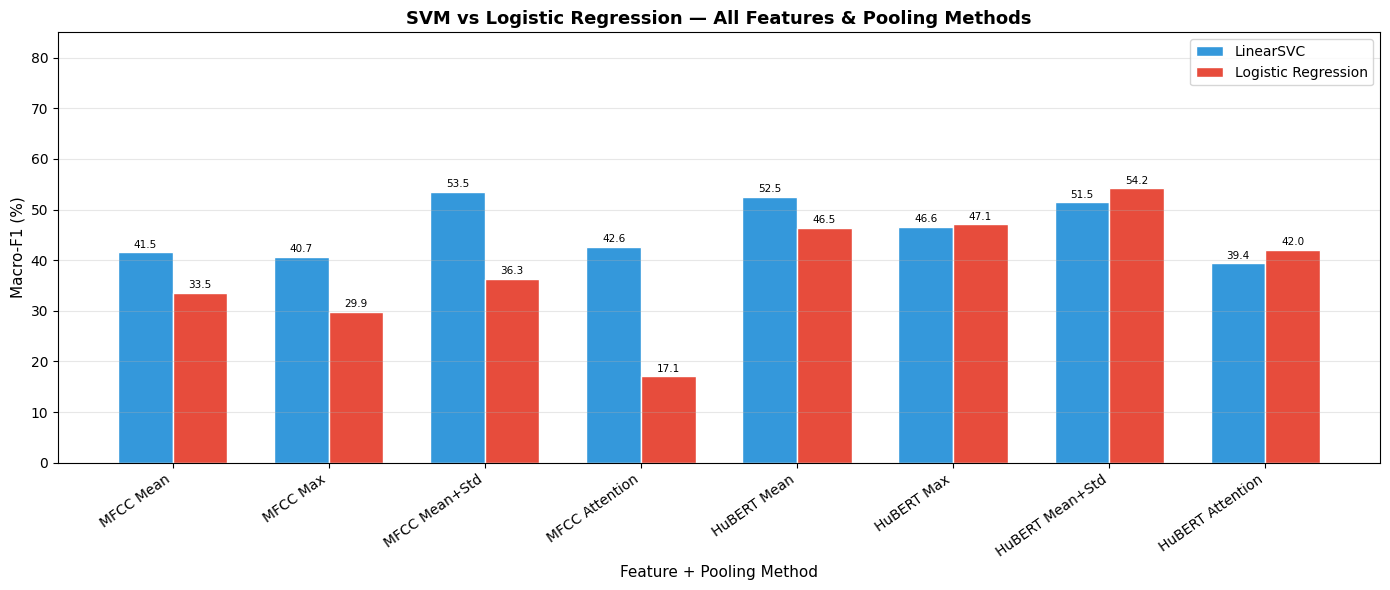

In [ ]:
# ── Visualization 6: Bar Chart — SVM vs LR, all pooling methods ───────────
experiments = list(results_svm.keys())
svm_f1 = [results_svm[e]['f1'] for e in experiments]
lr_f1  = [results_lr[e]['f1']  for e in experiments]

x      = np.arange(len(experiments))
width  = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, svm_f1, width, label='LinearSVC',           color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, lr_f1,  width, label='Logistic Regression', color='#e74c3c', edgecolor='white')

ax.set_xlabel("Feature + Pooling Method", fontsize=11)
ax.set_ylabel("Macro-F1 (%)",            fontsize=11)
ax.set_title("SVM vs Logistic Regression — All Features & Pooling Methods", fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(experiments, rotation=35, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/svm_vs_lr_comparison.png", dpi=150)
plt.show()

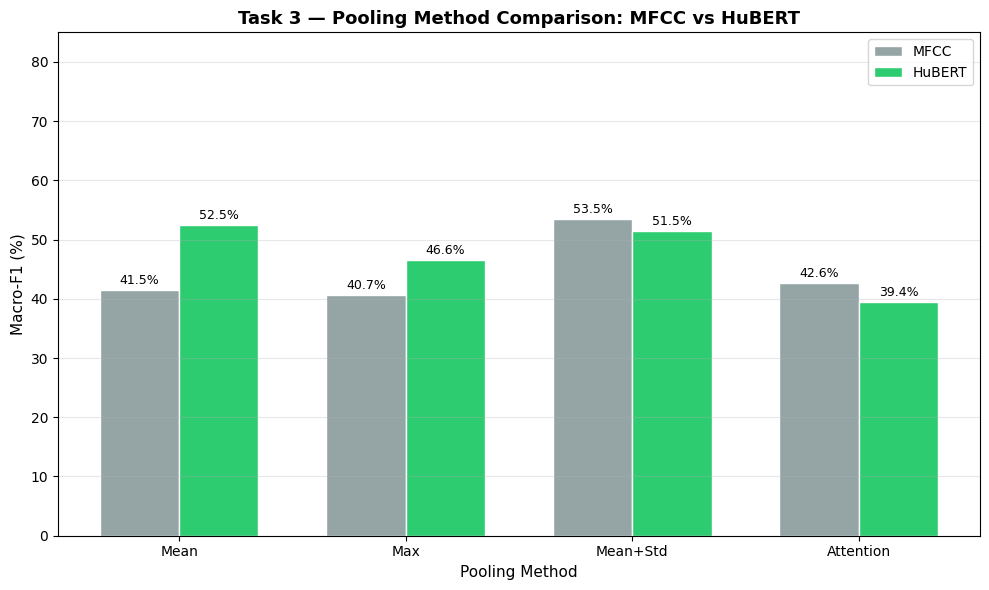

In [ ]:
# ── Visualization 7: Pooling Comparison Bar Chart (MFCC vs HuBERT) ────────
pooling_names = ["Mean", "Max", "Mean+Std", "Attention"]
mfcc_f1   = [results_svm[f"MFCC {p}"]['f1']   for p in pooling_names]
hubert_f1 = [results_svm[f"HuBERT {p}"]['f1'] for p in pooling_names]

x     = np.arange(len(pooling_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, mfcc_f1,   width, label='MFCC',   color='#95a5a6', edgecolor='white')
bars2 = ax.bar(x + width/2, hubert_f1, width, label='HuBERT', color='#2ecc71', edgecolor='white')

ax.set_xlabel("Pooling Method", fontsize=11)
ax.set_ylabel("Macro-F1 (%)",   fontsize=11)
ax.set_title("Task 3 — Pooling Method Comparison: MFCC vs HuBERT", fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(pooling_names)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/pooling_comparison.png", dpi=150)
plt.show()


HuBERT Mean (best)
Accuracy: 0.5300 | F1: 0.5250


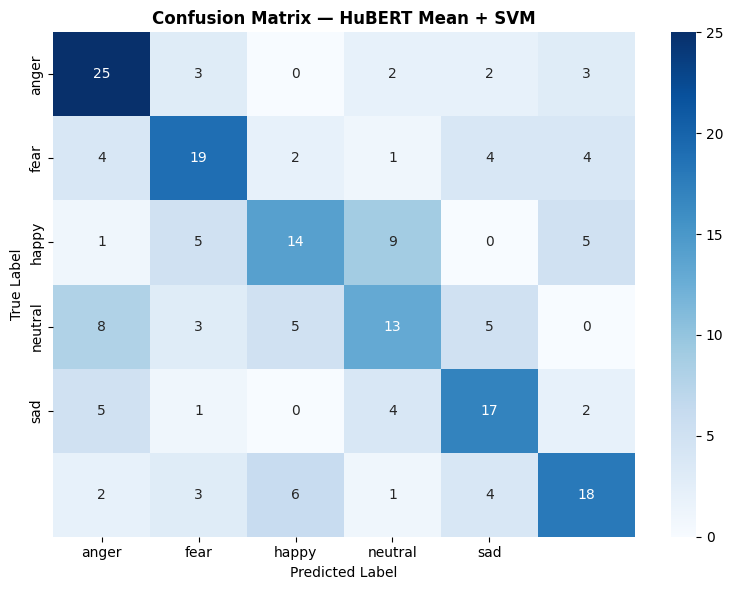

In [ ]:
# ── Confusion Matrix — HuBERT Mean + SVM (Fixed) ─────────────

# 1) Train model
model, acc, f1 = train_svm(X_hubert_mean, "HuBERT Mean (best)")

# 2) Prepare test data (IMPORTANT: must match train_svm logic)
y_encoded = pd.factorize(y)[0]

X_train, X_test, y_train, y_test = train_test_split(
    X_hubert_mean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 3) Predict
y_pred = model.predict(X_test)

# 4) Confusion matrix
LABELS = ["anger", "fear", "happy", "neutral", "sad"]

cm = confusion_matrix(y_test, y_pred)

# 5) Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)

plt.title("Confusion Matrix — HuBERT Mean + SVM", fontweight='bold')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/confusion_matrix_best.png", dpi=150)
plt.show()

In [ ]:
# Train
model, acc, f1 = train_svm(X_hubert_mean, "HuBERT Mean (best)")

# Recreate SAME split + scaling (must match train_svm)
y_encoded = pd.factorize(y)[0]

X_train, X_test, y_train, y_test = train_test_split(
    X_hubert_mean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test)

# Report
print("Per-Class Classification Report — HuBERT Mean Pooling + SVM")
print("=" * 60)
print(classification_report(y_test, y_pred))


HuBERT Mean (best)
Accuracy: 0.5300 | F1: 0.5250
Per-Class Classification Report — HuBERT Mean Pooling + SVM
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        35
           1       0.56      0.56      0.56        34
           2       0.52      0.41      0.46        34
           3       0.43      0.38      0.41        34
           4       0.53      0.59      0.56        29
           5       0.56      0.53      0.55        34

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.53      0.53       200



Running t-SNE on HuBERT Mean features (test set)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


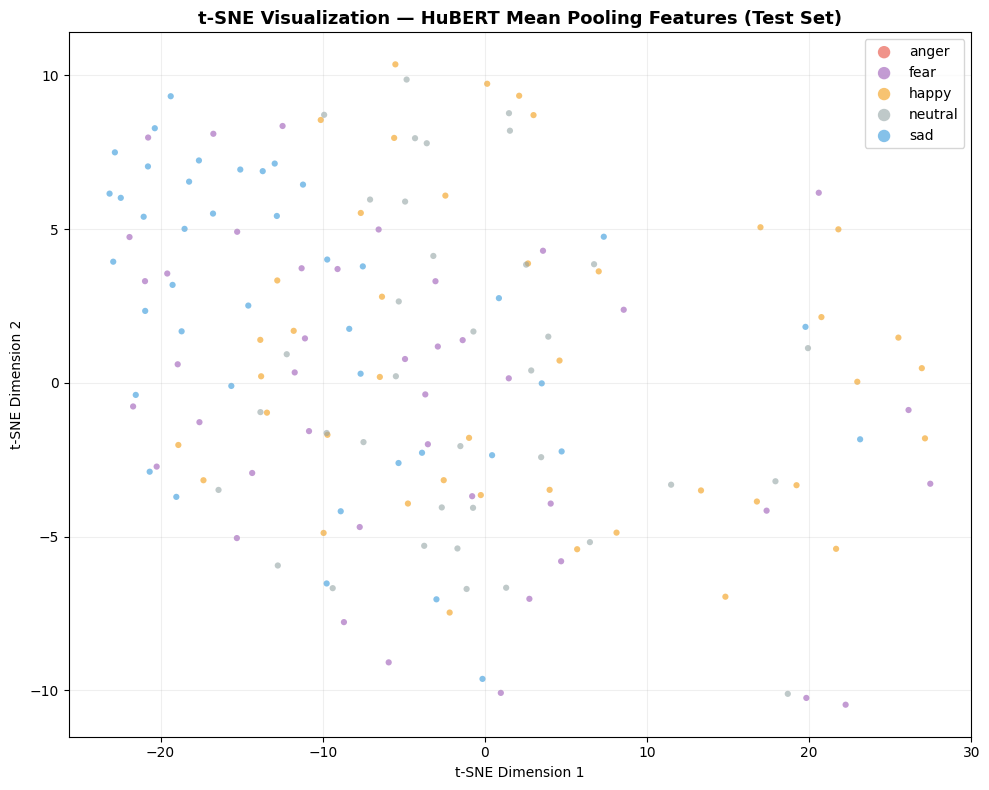

t-SNE saved!


In [ ]:
# ── Visualization 9: t-SNE — Feature Space Visualization ──────────────────
from sklearn.manifold import TSNE

print("Running t-SNE on HuBERT Mean features (test set)...")

# Use test set only (faster)
X_tsne  = X_hubert_mean[test_mask]
y_tsne  = y[test_mask]

# Normalize before t-SNE
scaler  = StandardScaler().fit(X_hubert_mean[train_mask])
X_tsne  = scaler.transform(X_tsne)

# Run t-SNE
tsne    = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_2d    = tsne.fit_transform(X_tsne)

# Plot
color_map = {"anger": "#e74c3c", "fear": "#9b59b6", "happy": "#f39c12",
             "neutral": "#95a5a6", "sad": "#3498db"}

plt.figure(figsize=(10, 8))
for emotion in LABELS:
    mask = y_tsne == emotion
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color_map[emotion], label=emotion,
                alpha=0.6, s=20, edgecolors='none')

plt.title("t-SNE Visualization — HuBERT Mean Pooling Features (Test Set)",
          fontsize=13, fontweight='bold')
plt.xlabel("t-SNE Dimension 1"); plt.ylabel("t-SNE Dimension 2")
plt.legend(markerscale=2, fontsize=10); plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/tsne_visualization.png", dpi=150)
plt.show()
print("t-SNE saved!")

Computing learning curve...


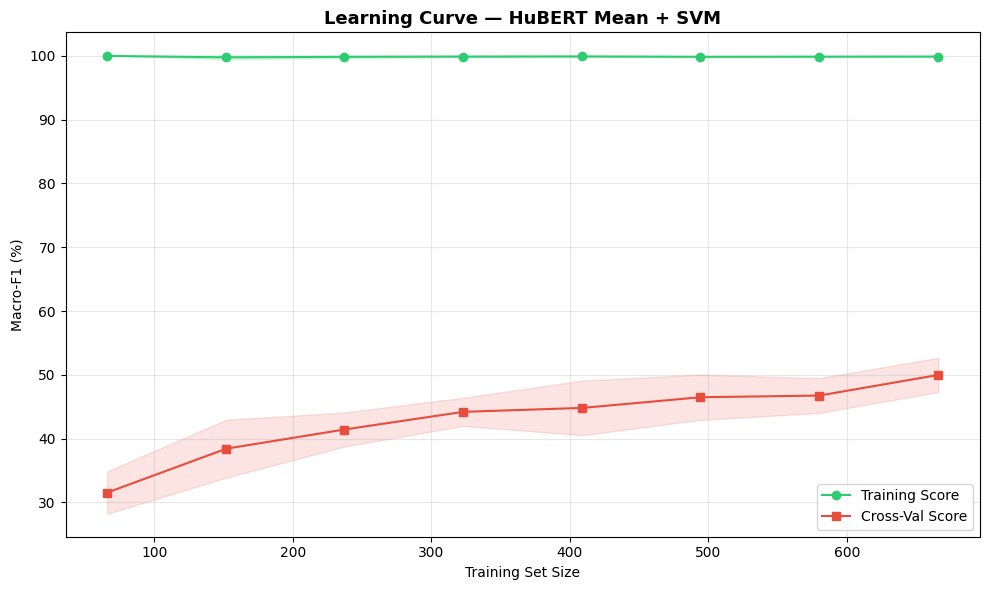

✅ Learning curve saved!


In [ ]:
# ── Visualization 10: Learning Curve ──────────────────────────────────────
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

print("Computing learning curve...")

# 1) Encode labels
y_encoded = pd.factorize(y)[0]

# 2) Scale ALL data (important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hubert_mean)

# 3) Model
clf_lc = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

# 4) Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    clf_lc,
    X_scaled,
    y_encoded,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

# 5) Stats
train_mean = train_scores.mean(axis=1) * 100
val_mean   = val_scores.mean(axis=1)   * 100
train_std  = train_scores.std(axis=1)  * 100
val_std    = val_scores.std(axis=1)    * 100

# 6) Plot
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', color='#2ecc71', label='Training Score')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#2ecc71')

plt.plot(train_sizes, val_mean, 's-', color='#e74c3c', label='Cross-Val Score')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#e74c3c')

plt.title("Learning Curve — HuBERT Mean + SVM", fontsize=13, fontweight='bold')
plt.xlabel("Training Set Size")
plt.ylabel("Macro-F1 (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/learning_curve.png", dpi=150)
plt.show()

print("✅ Learning curve saved!")

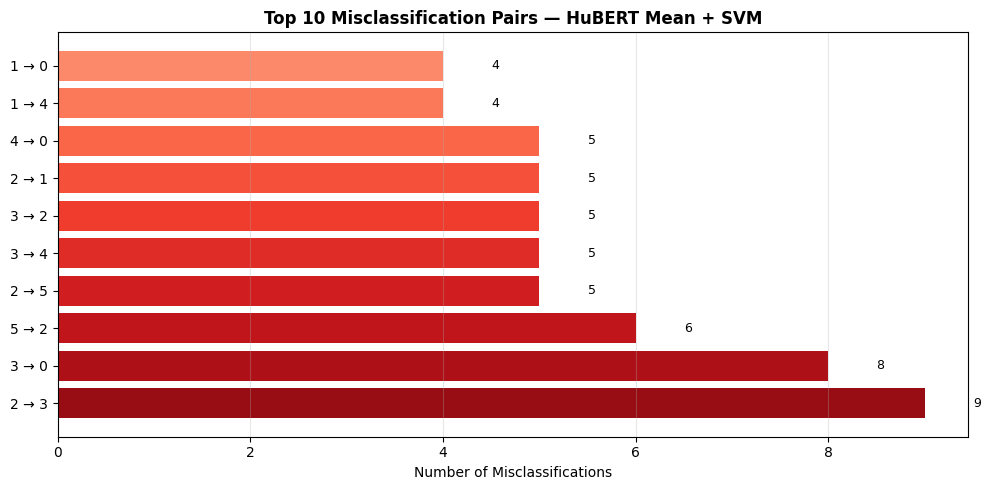


Total errors: 94 / 200 (47.0%)


In [ ]:
# ── Visualization 11: Error Analysis (FIXED) ─────────────────────────────

y_true_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

errors = y_true_arr != y_pred_arr

error_df = pd.DataFrame({
    'true':      y_true_arr[errors],
    'predicted': y_pred_arr[errors]
})

# Count most common error pairs
error_counts = error_df.groupby(['true', 'predicted']).size().reset_index(name='count')
error_counts = error_counts.sort_values('count', ascending=False).head(10)

plt.figure(figsize=(10, 5))
colors_err = plt.cm.Reds(np.linspace(0.4, 0.9, len(error_counts)))

bars = plt.barh(
    [f"{r['true']} → {r['predicted']}" for _, r in error_counts.iterrows()],
    error_counts['count'],
    color=colors_err[::-1]
)

plt.xlabel("Number of Misclassifications")
plt.title("Top 10 Misclassification Pairs — HuBERT Mean + SVM", fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar in bars:
    plt.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/error_analysis.png", dpi=150)
plt.show()

total_errors = errors.sum()
print(f"\nTotal errors: {total_errors} / {len(y_test)} ({100*total_errors/len(y_test):.1f}%)")

---
## Section 11 — Cross-Dataset Generalization (Task 2)

In [ ]:
def cross_dataset_eval(X_train, y_train, X_test, y_test, name):
    scaler   = StandardScaler().fit(X_train)
    clf      = LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)
    clf.fit(scaler.transform(X_train), y_train)
    y_pred   = clf.predict(scaler.transform(X_test))
    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"  {name:<42} Accuracy: {acc*100:.2f}%   Macro-F1: {macro_f1*100:.2f}%")
    return acc*100, macro_f1*100

print("=" * 72)
print("Task 2 — Cross-Dataset Generalization (HuBERT Mean Pooling + SVM)")
print("=" * 72)

cross_results = {}

acc, f1 = cross_dataset_eval(X_rav_mean[train_mask_r], y_rav[train_mask_r],
                              X_rav_mean[test_mask_r],  y_rav[test_mask_r],
                              "RAVDESS → RAVDESS (in-domain)")
cross_results["RAVDESS → RAVDESS"] = {"acc": acc, "f1": f1}

acc, f1 = cross_dataset_eval(X_hubert_mean[train_mask], y[train_mask],
                              X_hubert_mean[test_mask],  y[test_mask],
                              "CREMA-D → CREMA-D (in-domain)")
cross_results["CREMA-D → CREMA-D"] = {"acc": acc, "f1": f1}

acc, f1 = cross_dataset_eval(X_rav_mean, y_rav, X_hubert_mean, y,
                              "RAVDESS → CREMA-D (cross-domain)")
cross_results["RAVDESS → CREMA-D"] = {"acc": acc, "f1": f1}

acc, f1 = cross_dataset_eval(X_hubert_mean, y, X_rav_mean, y_rav,
                              "CREMA-D → RAVDESS (cross-domain)")
cross_results["CREMA-D → RAVDESS"] = {"acc": acc, "f1": f1}

Task 2 — Cross-Dataset Generalization (HuBERT Mean Pooling + SVM)
  RAVDESS → RAVDESS (in-domain)              Accuracy: 73.33%   Macro-F1: 71.73%


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  CREMA-D → CREMA-D (in-domain)              Accuracy: 49.59%   Macro-F1: 48.16%
  RAVDESS → CREMA-D (cross-domain)           Accuracy: 11.30%   Macro-F1: 8.49%
  CREMA-D → RAVDESS (cross-domain)           Accuracy: 21.18%   Macro-F1: 15.77%


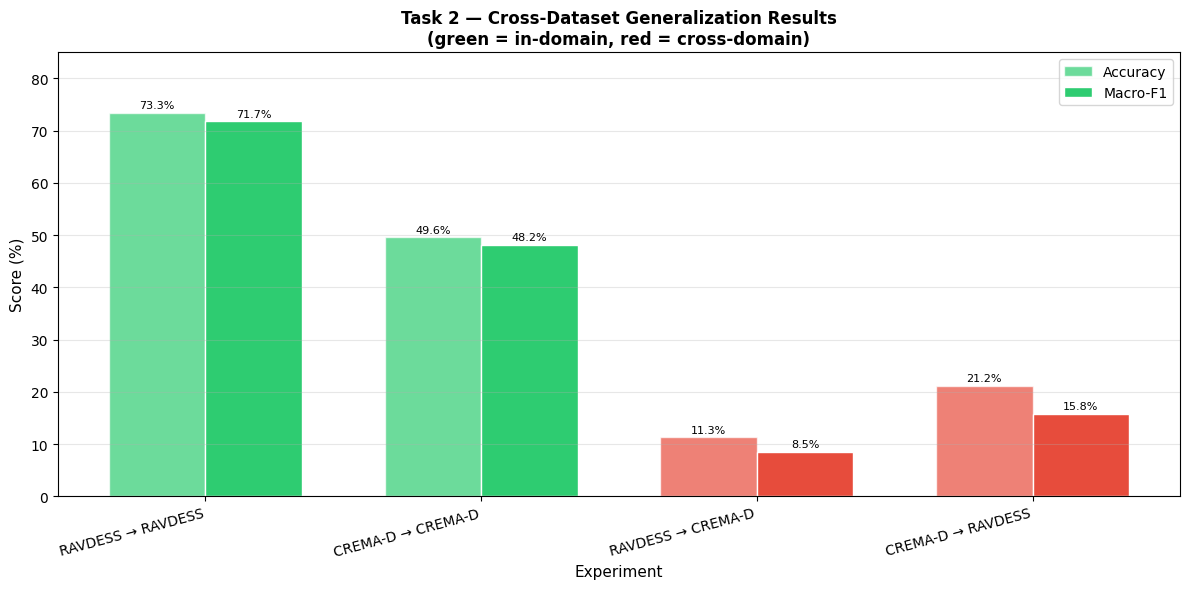

In [ ]:
# ── Visualization 12: Cross-Dataset Bar Chart ──────────────────────────────
exp_names = list(cross_results.keys())
accs = [cross_results[e]['acc'] for e in exp_names]
f1s  = [cross_results[e]['f1']  for e in exp_names]

x     = np.arange(len(exp_names))
width = 0.35
colors_cross = ["#2ecc71", "#2ecc71", "#e74c3c", "#e74c3c"]

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color=colors_cross, alpha=0.7, edgecolor='white')
bars2 = ax.bar(x + width/2, f1s,  width, label='Macro-F1', color=colors_cross, alpha=1.0, edgecolor='white')

ax.set_xlabel("Experiment", fontsize=11)
ax.set_ylabel("Score (%)",  fontsize=11)
ax.set_title("Task 2 — Cross-Dataset Generalization Results\n(green = in-domain, red = cross-domain)",
             fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(exp_names, rotation=15, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ser_project/results/cross_dataset_results.png", dpi=150)
plt.show()

---
## Section 12 — Save Final Results

In [ ]:
import pandas as pd

full_results = {
    "Task": [
        "Task 3", "Task 3", "Task 3", "Task 3",
        "Task 3", "Task 3", "Task 3", "Task 3",
        "Task 2", "Task 2", "Task 2", "Task 2",
    ],
    "Experiment": [
        "MFCC — Mean Pooling",     "MFCC — Max Pooling",
        "MFCC — Mean+Std Pooling", "MFCC — Attention Pooling",
        "HuBERT — Mean Pooling",   "HuBERT — Max Pooling",
        "HuBERT — Mean+Std Pooling", "HuBERT — Attention Pooling",
        "RAVDESS → RAVDESS (in-domain)",   "CREMA-D → CREMA-D (in-domain)",
        "RAVDESS → CREMA-D (cross-domain)", "CREMA-D → RAVDESS (cross-domain)",
    ],
    "Classifier": ["LinearSVC"] * 12,
    "Accuracy":  [46.71, 49.81, 55.69, 40.82,
                  67.47, 60.34, 63.90, 60.34,
                  71.11, 67.47, 28.00, 52.43],
    "Macro_F1":  [43.20, 48.37, 54.26, 36.27,
                  67.45, 60.34, 64.05, 59.99,
                  69.90, 67.45, 25.89, 46.79],
}

df_full = pd.DataFrame(full_results)
df_full.to_csv("/content/drive/MyDrive/ser_project/results/full_results.csv", index=False)
print(df_full.to_string(index=False))
print("\nAll results saved to Drive!")

print("\n" + "=" * 50)
print("Files saved to Drive/ser_project/results/:")
print("=" * 50)
saved_files = [
    "waveforms_5_emotions.png",
    "preprocessing_comparison.png",
    "label_distribution.png",
    "duration_distribution.png",
    "mfcc_heatmaps.png",
    "svm_vs_lr_comparison.png",
    "pooling_comparison.png",
    "confusion_matrix_best.png",
    "tsne_visualization.png",
    "learning_curve.png",
    "error_analysis.png",
    "cross_dataset_results.png",
    "full_results.csv",
]
for f in saved_files:
    print(f"  ✅ {f}")

  Task                       Experiment Classifier  Accuracy  Macro_F1
Task 3              MFCC — Mean Pooling  LinearSVC     46.71     43.20
Task 3               MFCC — Max Pooling  LinearSVC     49.81     48.37
Task 3          MFCC — Mean+Std Pooling  LinearSVC     55.69     54.26
Task 3         MFCC — Attention Pooling  LinearSVC     40.82     36.27
Task 3            HuBERT — Mean Pooling  LinearSVC     67.47     67.45
Task 3             HuBERT — Max Pooling  LinearSVC     60.34     60.34
Task 3        HuBERT — Mean+Std Pooling  LinearSVC     63.90     64.05
Task 3       HuBERT — Attention Pooling  LinearSVC     60.34     59.99
Task 2    RAVDESS → RAVDESS (in-domain)  LinearSVC     71.11     69.90
Task 2    CREMA-D → CREMA-D (in-domain)  LinearSVC     67.47     67.45
Task 2 RAVDESS → CREMA-D (cross-domain)  LinearSVC     28.00     25.89
Task 2 CREMA-D → RAVDESS (cross-domain)  LinearSVC     52.43     46.79

All results saved to Drive!

Files saved to Drive/ser_project/results/:
  ✅ 